In [1]:
import xarray as xr
import numpy as np
from osgeo import ogr, osr
import rioxarray
from datetime import datetime,timedelta
import matplotlib.pylab as plt
import matplotlib
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
from matplotlib.dates import MonthLocator, YearLocator
from pyproj import Transformer
matplotlib.use('nbAgg')
import pandas as pd
from rasterstats import zonal_stats, gen_zonal_stats
from matplotlib.patches import Polygon

import fiona
import rasterio
import rasterio.plot
import matplotlib as mpl

import sys
sys.path.insert(0,'/workspace/WorldPeatland/code/')
from gdal_sheep import create_xarr, gdal_dt, _get_FillValue, get_NoDataValue
from save_xarray_to_gtiff_old import save_xarray_old
from utils import proj4_extract
import matplotlib.dates as mdates

#### Enter the site name 

In [2]:
site='Quebec'

path = f'/wp_data/sites/{site}/MODIS/timeSeries/'

#### Get the descaled LST time series 

In [3]:
# LST DAY linear.smoothn.descaled
fpath = path + 'MYD11A1.061._LST_Day_1km.linear.smoothn.0.5.descaled.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstDay = create_xarr(opn, 'LST', arr, dts)

# LST NIGHT linear.smoothn.descaled
fpath = path + 'MYD11A1.061._LST_Night_1km.linear.smoothn.0.5.descaled.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstNight = create_xarr(opn, 'LST', arr, dts)

In [4]:
opn_ref = opn
opn_ref

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7fc845787f60> >

#### Calculate LST Diurnal = LST day - LST night

In [5]:
# Actual smoothened Observations of LSTs
# Difference between day and night LST 
xr_lstDay['LST_diurnal'] = xr_lstDay['LST'] - xr_lstNight['LST']

#### Add crs to be able to save the computed LST diurnal

In [6]:
proj4_str = proj4_extract(opn)
xr_lstDay.attrs['crs'] = proj4_str

#### Get the Fill value from the time series and add it to the calculated LST diurnal 

In [7]:
NoDataValue = get_NoDataValue(opn)

# Add FillValue to attributes
xr_lstDay.attrs['_FillValue'] = NoDataValue

#### Create output fname + save the xarray 

In [8]:
output_fname = path + 'MYD11A1.061._LST_Diurnal_1km.linear.smoothn.0.5.descaled.tif'

In [9]:
# save the xarray into a tif file 
save_xarray_old(output_fname, xr_lstDay, 'LST_diurnal', opn_ref.GetGeoTransform())

INFO:save_xarray_to_gtiff_old:save_xarray_to_gtiff_old successful


#### Detrend the calculated difference 
### LST diurnal detrended

In [10]:
trend_ds = xr_lstDay['LST_diurnal'].rolling(time=int(365), min_periods=1, center=True).mean()
ds_diur_dtr = trend_ds.to_dataset(name='LST_diurnal')

ds_diur_dtr.attrs['crs'] = proj4_str

# Add FillValue to attributes
ds_diur_dtr.attrs['_FillValue'] = NoDataValue

In [11]:
output_fname = path + 'MYD11A1.061._LST_Diurnal_1km.linear.smoothn.0.5.descaled.detrended.tif'

# save the xarray into a tif file 
save_xarray_old(output_fname, ds_diur_dtr, 'LST_diurnal', opn_ref.GetGeoTransform())

INFO:save_xarray_to_gtiff_old:save_xarray_to_gtiff_old successful


In [12]:
output_fname

'/wp_data/sites/Quebec/MODIS/timeSeries/MYD11A1.061._LST_Diurnal_1km.linear.smoothn.0.5.descaled.detrended.tif'

In [13]:
# Check for 0 values 

In [14]:
np.where(xr_lstDay['LST'].values==0)

(array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))

In [15]:
# xr_lstDay['LST'].isel(time=968, latitude=11, longitude=9)

In [16]:
# xr_lstNight['LST'].isel(time=968, latitude=11, longitude=9)

## Plot

In [17]:
# Pick a random pixel index
lat_idx = np.random.randint(0, ds_diur_dtr.dims['latitude'])
lon_idx = np.random.randint(0, ds_diur_dtr.dims['longitude'])

print(f"Random pixel index: latitude = {lat_idx}, longitude = {lon_idx}")

# Get coordinate values
lat_val = ds_diur_dtr['latitude'].isel({'latitude': lat_idx}).item()
lon_val = ds_diur_dtr['longitude'].isel({'longitude': lon_idx}).item()
print(f"Coordinads_diur_dtrtes: lat = {lat_val}, lon = {lon_val}")

Random pixel index: latitude = 1, longitude = 20
Coordinads_diur_dtrtes: lat = 5319293.298933386, lon = -5179372.858529373


<IPython.core.display.Javascript object>


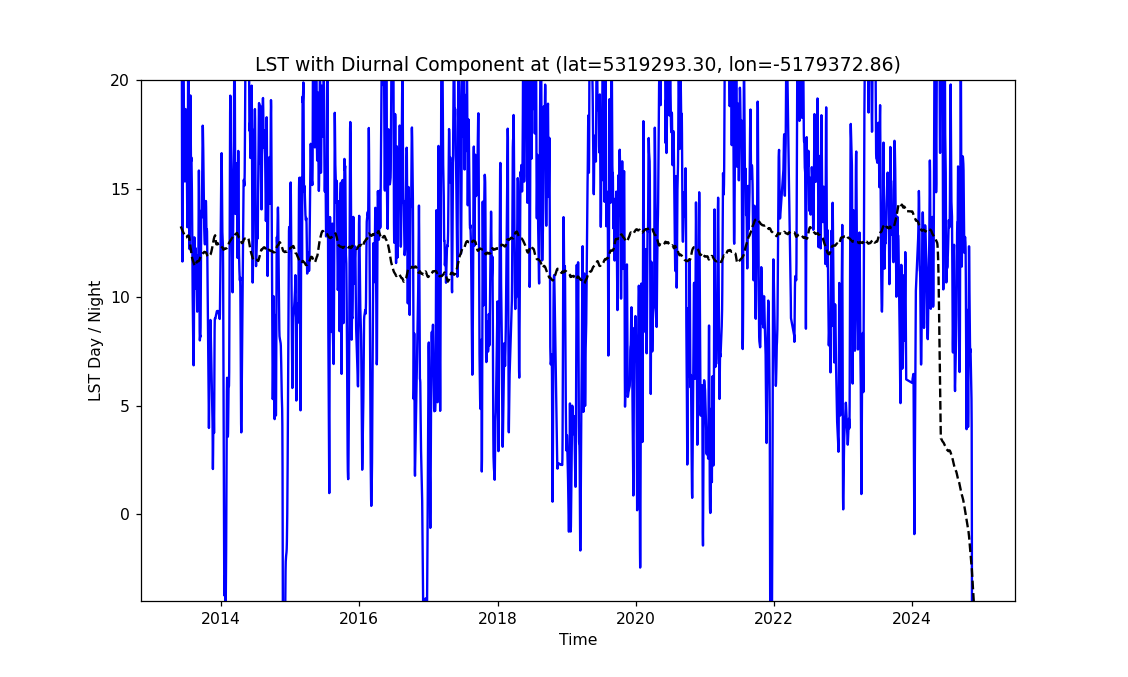

In [18]:
# Extract data for the same pixel
pixel_data_1 = xr_lstDay['LST_diurnal'].isel({'latitude': lat_idx, 'longitude': lon_idx})
pixel_data_2 = ds_diur_dtr['LST_diurnal'].isel({'latitude': lat_idx, 'longitude': lon_idx})

# Create figure and main axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot LST Day and LST Night on primary y-axis
ax.plot(pixel_data_1['time'], pixel_data_1, label='LST Day', color='blue', linestyle='-')
ax.plot(pixel_data_2['time'], pixel_data_2, label='LST Night', color='black', linestyle='--')

ax.set_xlabel('Time')
ax.set_ylabel('LST Day / Night')
ax.tick_params(axis='y')
ax.set_ylim(-4, 20)


plt.title(f'LST with Diurnal Component at (lat={lat_val:.2f}, lon={lon_val:.2f})')
plt.show()


#### Get the descaled + detrended LST time series 

In [19]:
# LST DAY linear.smoothn.descaled.detrended
fpath = path + 'MYD11A1.061._LST_Day_1km.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstDay_dtr = create_xarr(opn, 'LST', arr, dts)

# LST NIGHT linear.smoothn.descaled.detrended
fpath = path + 'MYD11A1.061._LST_Night_1km.linear.smoothn.0.5.descaled.detrended.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstNight_dtr = create_xarr(opn, 'LST', arr, dts)

##### Get a random pixel

In [20]:
# Pick a random pixel index
lat_idx = np.random.randint(0, ds_diur_dtr.dims['latitude'])
lon_idx = np.random.randint(0, ds_diur_dtr.dims['longitude'])

print(f"Random pixel index: latitude = {lat_idx}, longitude = {lon_idx}")

# Get coordinate values
lat_val = ds_diur_dtr['latitude'].isel({'latitude': lat_idx}).item()
lon_val = ds_diur_dtr['longitude'].isel({'longitude': lon_idx}).item()
print(f"Coordinates: lat = {lat_val}, lon = {lon_val}")

Random pixel index: latitude = 2, longitude = 9
Coordinates: lat = 5318366.673500247, lon = -5189565.738293904


<IPython.core.display.Javascript object>


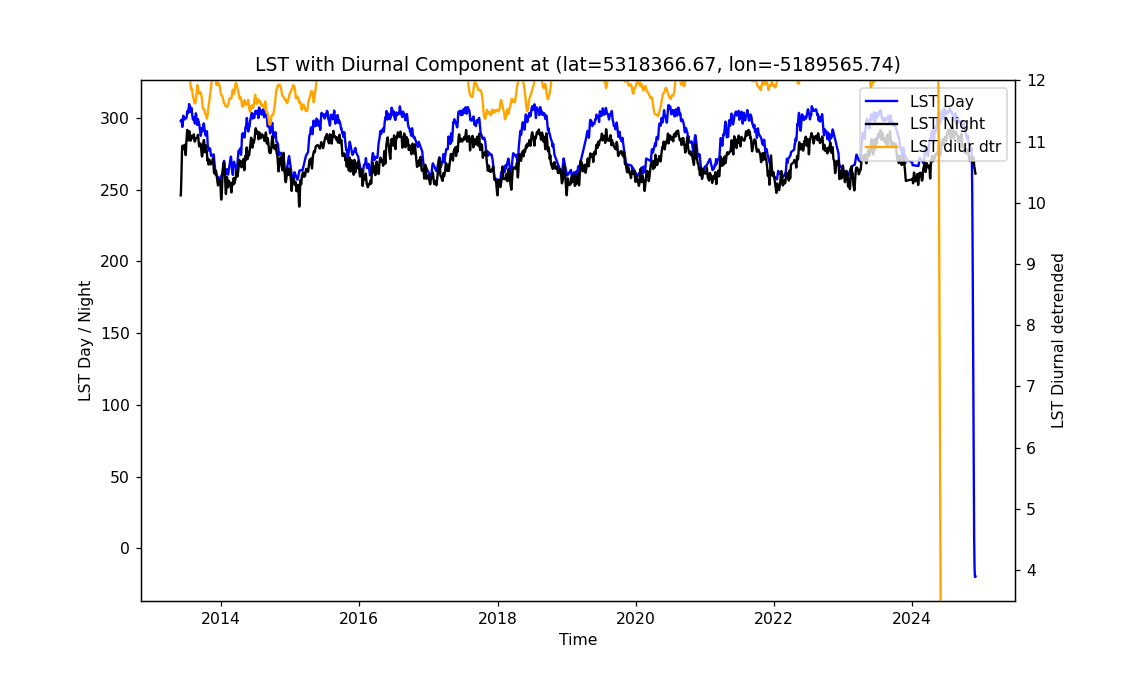

In [21]:
# Extract data for the same pixel
pixel_data_1 = ds_diur_dtr['LST_diurnal'].isel({'latitude': lat_idx, 'longitude': lon_idx})
pixel_data_2 = xr_lstDay['LST'].isel({'latitude': lat_idx, 'longitude': lon_idx})
pixel_data_3 = xr_lstNight['LST'].isel({'latitude': lat_idx, 'longitude': lon_idx})

# Create figure and main axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot LST Day and LST Night on primary y-axis
ax1.plot(pixel_data_2['time'], pixel_data_2, label='LST Day', color='blue', linestyle='-')
ax1.plot(pixel_data_3['time'], pixel_data_3, label='LST Night', color='black', linestyle='-')

ax1.set_xlabel('Time')
ax1.set_ylabel('LST Day / Night')
ax1.tick_params(axis='y')

# Create secondary y-axis for LST diurnal
ax2 = ax1.twinx()
ax2.plot(pixel_data_1['time'], pixel_data_1, label='LST diur dtr', color='orange', linestyle='-')
ax2.set_ylabel('LST Diurnal detrended')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')


ax2.set_ylim(3.5, 12)


plt.title(f'LST with Diurnal Component at (lat={lat_val:.2f}, lon={lon_val:.2f})')
plt.show()


<IPython.core.display.Javascript object>


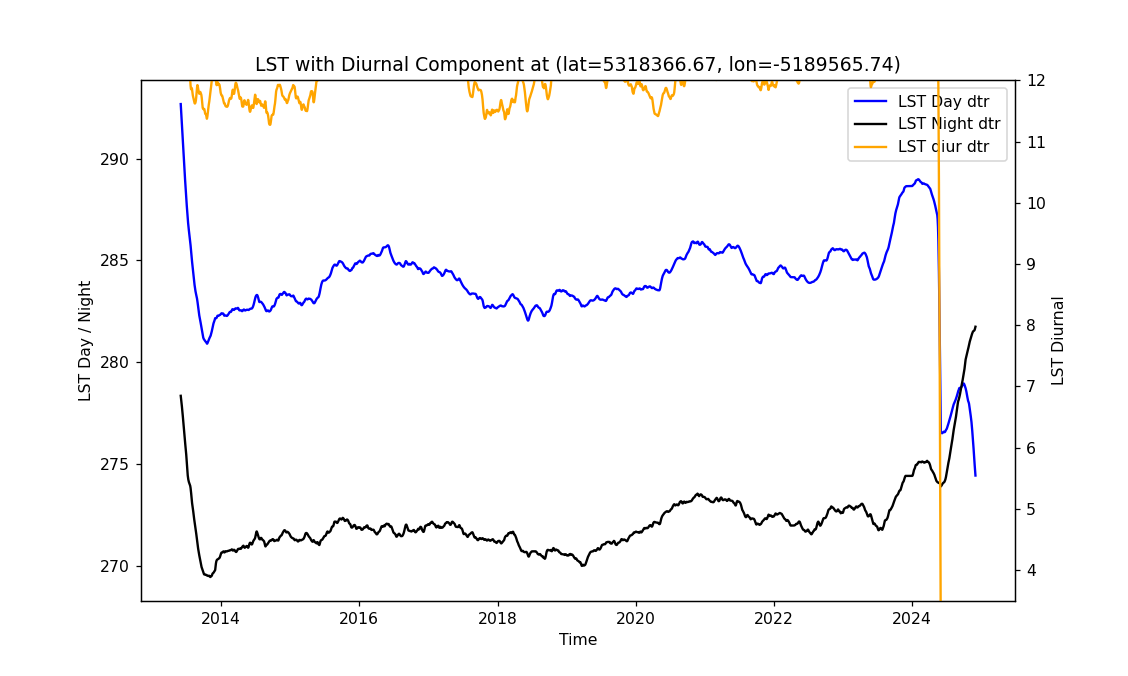

In [22]:
# Extract data for the same pixel
pixel_data_1 = ds_diur_dtr['LST_diurnal'].isel({'latitude': lat_idx, 'longitude': lon_idx})
pixel_data_2 = xr_lstDay_dtr['LST'].isel({'latitude': lat_idx, 'longitude': lon_idx})
pixel_data_3 = xr_lstNight_dtr['LST'].isel({'latitude': lat_idx, 'longitude': lon_idx})

# Create figure and main axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot LST Day and LST Night on primary y-axis
ax1.plot(pixel_data_2['time'], pixel_data_2, label='LST Day dtr', color='blue', linestyle='-')
ax1.plot(pixel_data_3['time'], pixel_data_3, label='LST Night dtr', color='black', linestyle='-')

ax1.set_xlabel('Time')
ax1.set_ylabel('LST Day / Night')
ax1.tick_params(axis='y')

# Create secondary y-axis for LST diurnal
ax2 = ax1.twinx()
ax2.plot(pixel_data_1['time'], pixel_data_1, label='LST diur dtr', color='orange', linestyle='-')
ax2.set_ylabel('LST Diurnal')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')


ax2.set_ylim(3.5, 12)


plt.title(f'LST with Diurnal Component at (lat={lat_val:.2f}, lon={lon_val:.2f})')
plt.show()


### Compute LST diurnal uncertainties
#### Get LST day and night uncertainties 

In [23]:
# LST DAY linear.smoothn std dev 
fpath = path + 'MYD11A1.061._LST_Day_1km.linear.smoothn.0.5_qa_weighted_std_dev.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstDay = create_xarr(opn, 'LST', arr, dts)

# LST NIGHT linear.smoothn std dev
fpath = path + 'MYD11A1.061._LST_Night_1km.linear.smoothn.0.5_qa_weighted_std_dev.tif'
arr, dts, opn = gdal_dt(fpath)
xr_lstNight = create_xarr(opn, 'LST', arr, dts)

#### Compute √(day² + night²) for each variable

In [24]:
uncertainty_diur = xr.Dataset()   
uncertainty_diur['LST'] = np.sqrt(xr_lstDay['LST']**2 + xr_lstNight['LST']**2)

In [25]:
# set 'crs'
uncertainty_diur.attrs['crs'] = proj4_str

# get fill value 
_FillValue = _get_FillValue(opn)

# Add FillValue to attributes
uncertainty_diur.attrs['_FillValue'] = _FillValue

# Rename dimensions
uncertainty_diur = uncertainty_diur.rename({'time': 'RANGEBEGINNINGDATE'})

In [26]:
output_fname = path + 'MYD11A1.061._LST_Diurnal_1km.linear.smoothn.0.5_std_dev.tif'

# save the xarray into a tif file 
save_xarray_old(output_fname, uncertainty_diur, 'LST', opn_ref.GetGeoTransform())

INFO:save_xarray_to_gtiff_old:save_xarray_to_gtiff_old successful


## Scratch

In [27]:
fpath = f'/wp_data/sites/{site}/MODIS/timeSeries/MYD11A1.061._LST_Diurnal_1km.linear.smoothn.0.5.descaled.tif'

arr, dts, opn = gdal_dt(fpath)
xr_lstDiur = create_xarr(opn, 'LST_diur', arr, dts)

In [28]:
fpath = '/wp_data/sites/Saddleworth/MODIS/timeSeries/MYD11A1.061._LST_Diurnal_1km.linear.smoothn.0.5.descaled.detrended.tif'

arr, dts, opn = gdal_dt(fpath)
xr_lstDiurdetr = create_xarr(opn, 'LST_diur', arr, dts)

In [29]:
# Pick a random pixel index
lat_idx = np.random.randint(0, xr_lstDiur.dims['latitude'])
lon_idx = np.random.randint(0, xr_lstDiur.dims['longitude'])

print(f"Random pixel index: latitude = {lat_idx}, longitude = {lon_idx}")

# Get coordinate values
lat_val = xr_lstDiur['latitude'].isel({'latitude': lat_idx}).item()
lon_val = xr_lstDiur['longitude'].isel({'longitude': lon_idx}).item()
print(f"Coordinates: lat = {lat_val}, lon = {lon_val}")

Random pixel index: latitude = 9, longitude = 11
Coordinates: lat = 5311880.295468274, lon = -5187712.487427625


<IPython.core.display.Javascript object>


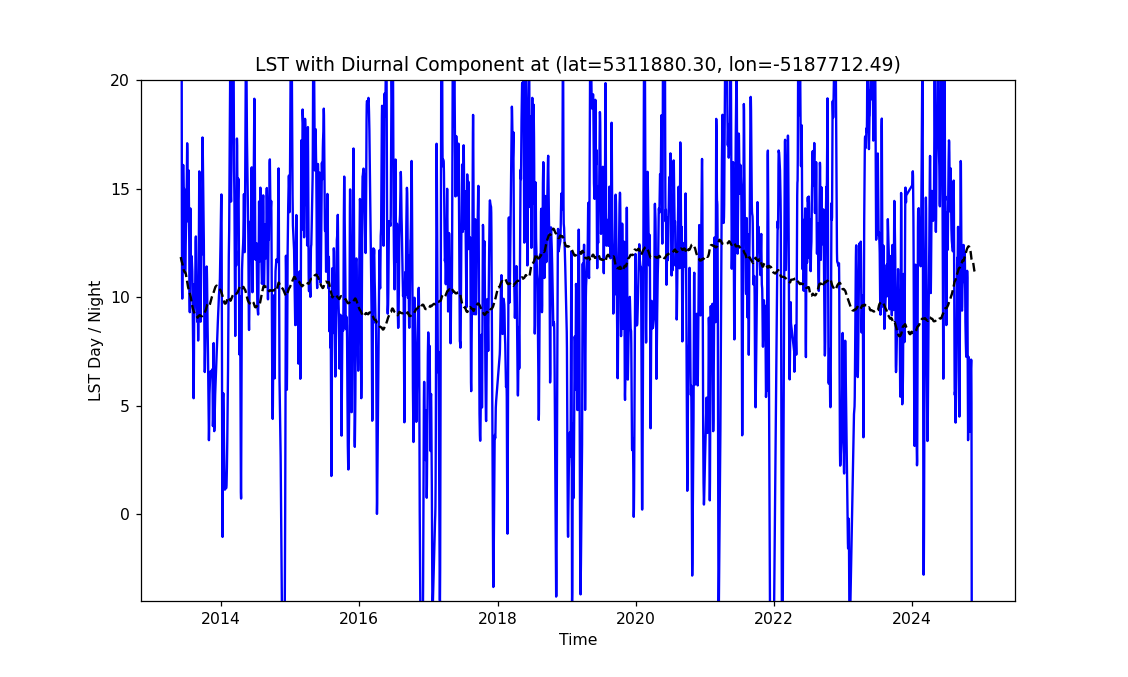

In [30]:
# Extract data for the same pixel
pixel_data_1 = xr_lstDiur['LST_diur'].isel({'latitude': lat_idx, 'longitude': lon_idx})
pixel_data_2 = xr_lstDiurdetr['LST_diur'].isel({'latitude': lat_idx, 'longitude': lon_idx})

# Create figure and main axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot LST Day and LST Night on primary y-axis
ax.plot(pixel_data_1['time'], pixel_data_1, label='LST Day', color='blue', linestyle='-')
ax.plot(pixel_data_2['time'], pixel_data_2, label='LST Night', color='black', linestyle='--')

ax.set_xlabel('Time')
ax.set_ylabel('LST Day / Night')
ax.tick_params(axis='y')
ax.set_ylim(-4, 20)


plt.title(f'LST with Diurnal Component at (lat={lat_val:.2f}, lon={lon_val:.2f})')
plt.show()
